In [12]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
from cfe.metric.metric_correlation_v2 import calculate_correlation
from cfe.metric.metric_position_predict_v3 import calculate_position_predict
from cfe.metric.metric_featureimp_v3 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
    fi_ranger_rf_lite
)
from cfe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones,calculate_mapping
from cfe.metric._topology_metric.metric_him import calculate_him
from cfe.metric.topology_metric import calc_isomorphic, calculate_edge_flip
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
fadata = cfe.data.read_erythroid_lineage()
fadata

[2025年05月04日 17时41分58秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    FateAnnData add_trajectory                                                        


AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

In [14]:
# fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
# fadata.obs.index

[2025年05月04日 17时41分59秒] DEBUG    plot_trajectory                                                             
[2025年05月04日 17时42分47秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年05月04日 17时42分53秒] DEBUG    add waypoints shape is (205, 9815), finished!                               
[2025年05月04日 17时42分56秒] DEBUG    plot_trajectory                                                             
[2025年05月04日 17时43分44秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年05月04日 17时43分51秒] DEBUG    add waypoints shape is (205, 9815), finished!                               


AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'

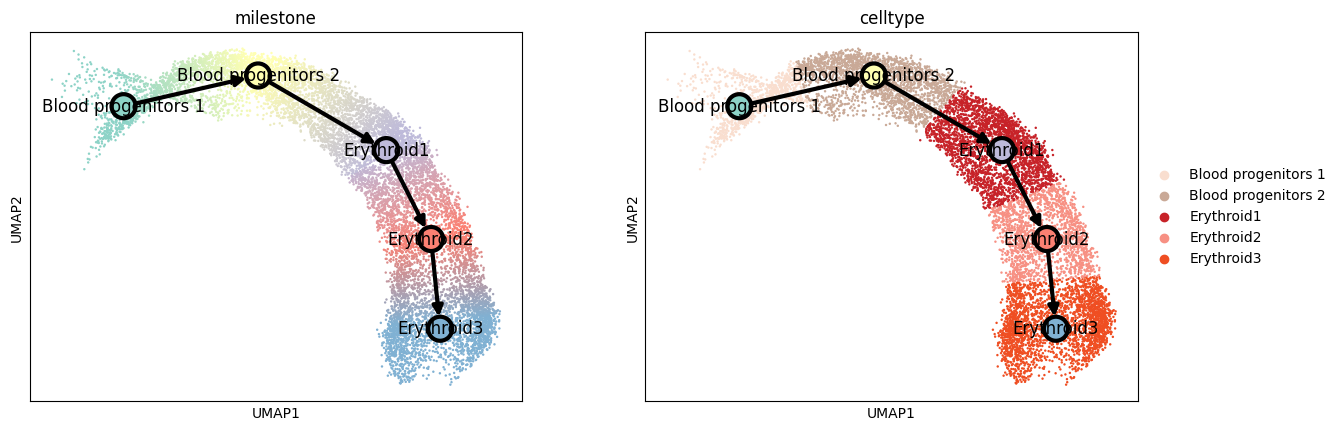

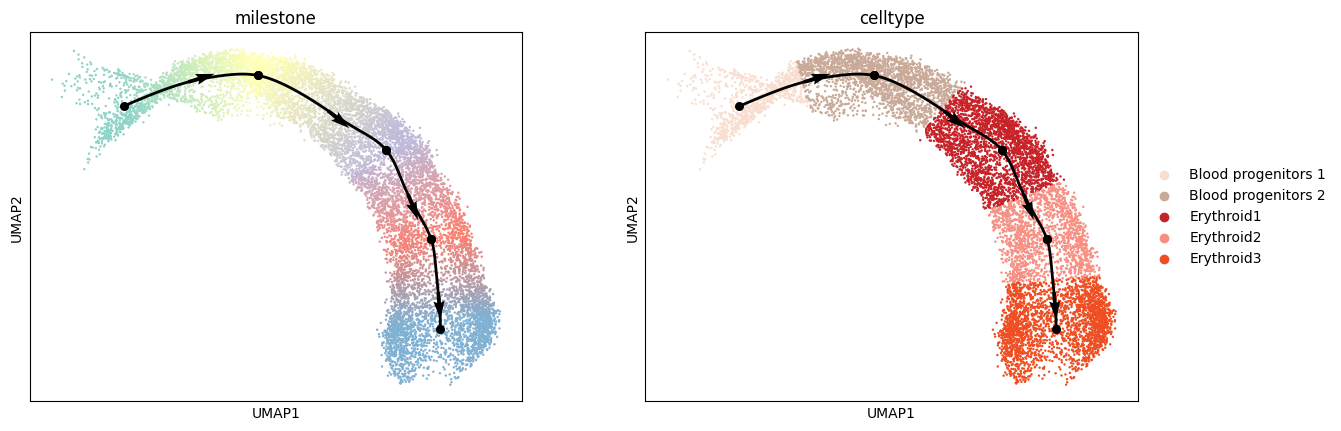

In [15]:
cluster_key = "celltype"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

basis = "umap"
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=False)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list, curve=True)
fadata

[2025年05月04日 17时44分53秒] INFO     find wrapper type: directed                                                 


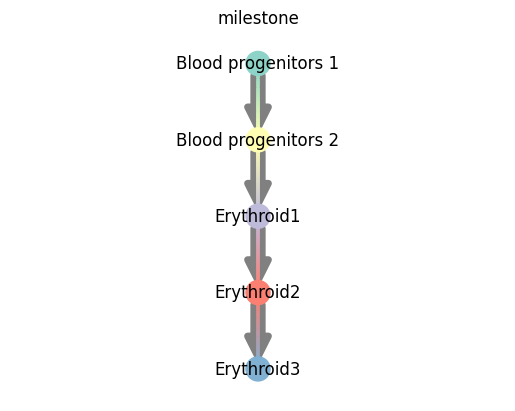

In [16]:
cfe.plot.plot_wrapper(fadata)

[2025年05月04日 17时46分19秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x7fe1703040d0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7fe1a75616c0>                                                                   
[2025年05月04日 17时46分21秒] DEBUG    Add trajectory by wrapper type: linear                                      
                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                    

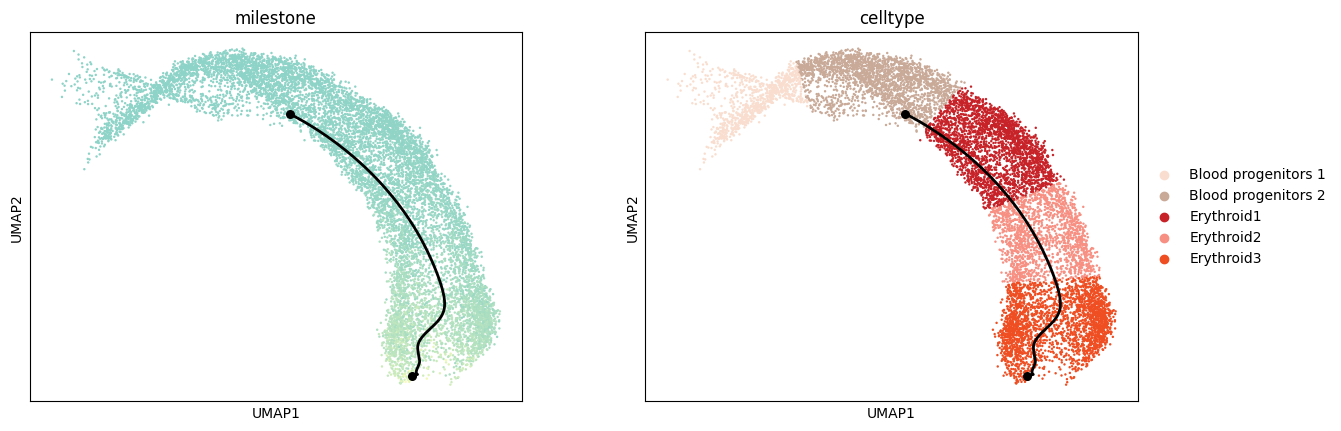

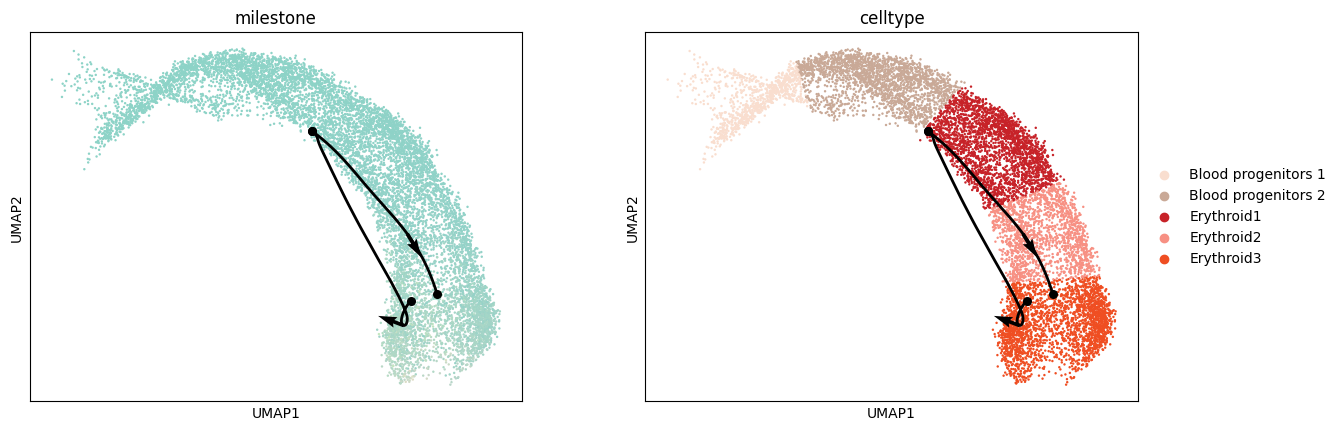

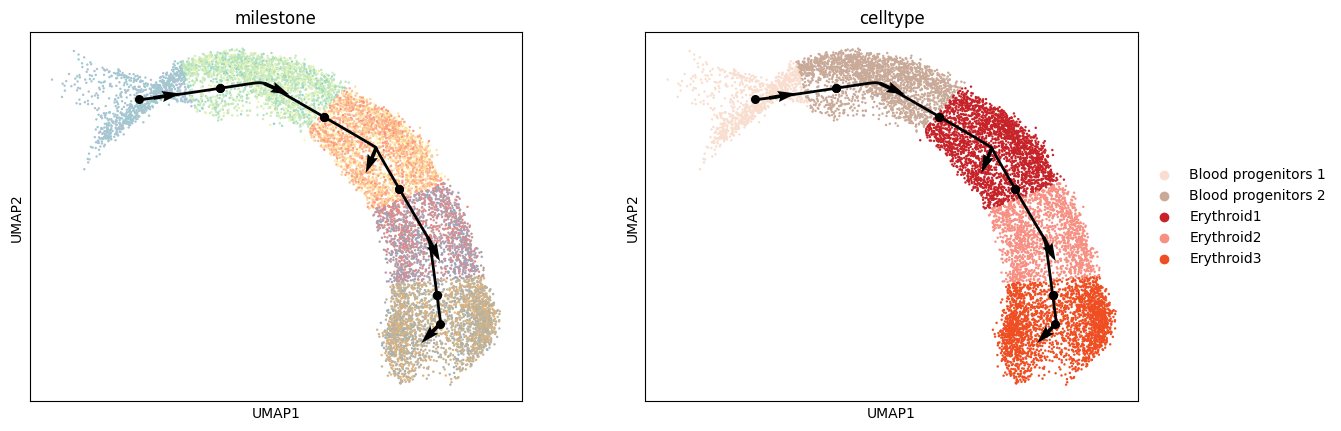

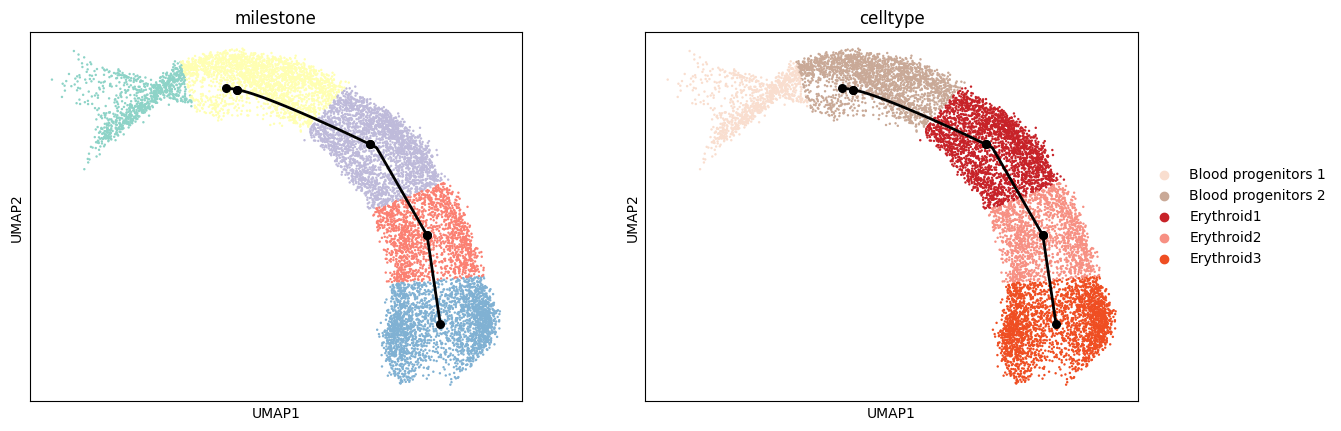

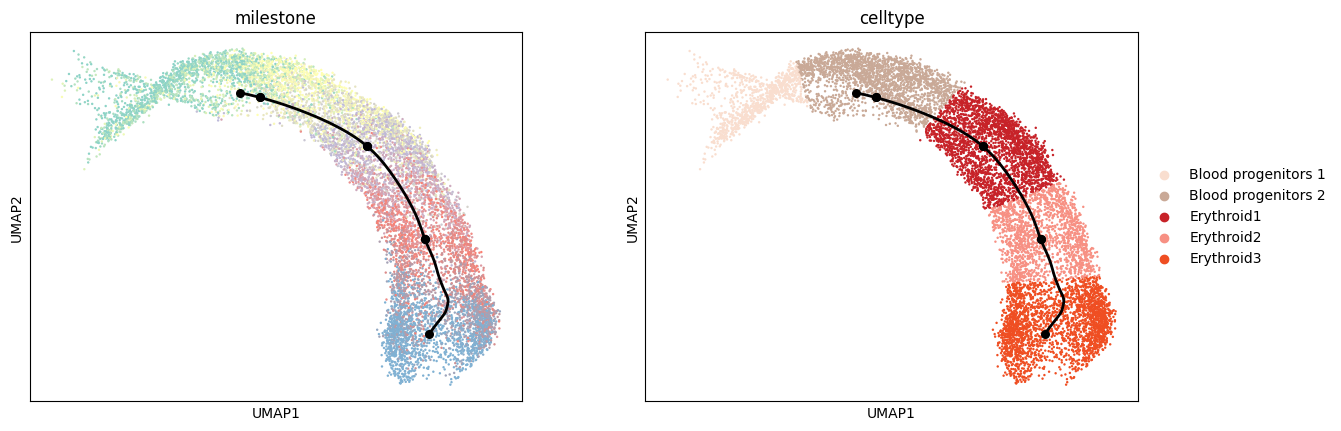

In [17]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata


method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]

for method_name in method_name_list:
    method = cfe.method.FateMethod(method_name=method_name)

    method.infer_trajectory(fadata)

    cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

In [18]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年05月04日 17时54分02秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'paga-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function'],
 ['ref',
  '20250504_174619__comp1-python_function__PJrlJzwoXG',
  '20250504_174724__state_comp-python_function__eX1fL6Znr1',
  '20250504_174831__paga-python_function__0JMFi2X1EA',
  '20250504_174935__cluster_mst-python_function__SNCCjRYlYu',
  '20250504_175035__projection_mst-python_function__xU3OfdO7NI'])

In [19]:
new_fadata = cfe.data.FateAnnData(
        X=fadata.X,
        obs=fadata.obs,
        uns=fadata.uns
    )
for i in model_name_list: 
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]['milestone_wrapper']
    new_fadata.add_waypoints()
    # 使用单引号避免冲突
    print(f"{i}'s milestone_network is:\n {new_fadata.milestone_wrapper['milestone_network']}")
    print(f"{i}'s progressions is:\n {new_fadata.milestone_wrapper['progressions']}")

    

prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

                        DEBUG    FateAnnData add_waypoints                                                         


ref's milestone_network is:
                   from                   to    length  directed
0  Blood progenitors 1  Blood progenitors 2  3.557667      True
1  Blood progenitors 2           Erythroid1  4.143259      True
2           Erythroid1           Erythroid2  3.067139      True
3           Erythroid2           Erythroid3  2.663271      True
ref's progressions is:
              cell_id                 from                   to  percentage
0     AAAGATCTCTCGAA  Blood progenitors 1  Blood progenitors 2    0.840560
1     AATCTCACTGCTTT  Blood progenitors 1  Blood progenitors 2    0.536894
2     AATGGCTGAAGATG  Blood progenitors 1  Blood progenitors 2    0.517314
3     ACACATCTGTCAAC  Blood progenitors 2           Erythroid1    0.349778
4     ACGACAACTGGAGG  Blood progenitors 2           Erythroid1    0.000379
...              ...                  ...                  ...         ...
2692  TTTCACGACTGGTA           Erythroid2           Erythroid3    0.648873
2693  TTTCAGTGCGAGTT       

In [20]:
metrics = cfe.metric.metrics
metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


拓扑部分(调用了简化)

In [ ]:
metric_topology_dict = {}
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_topology_dict[model_name] = model_metric

df1 = pd.DataFrame(metric_topology_dict).T
df1.index=parsed_model_name_list
df1

,isomorphic,edge_flip,him
ref,1.0,1.0,1.000000
comp1-python_function,1.0,1.0,1.000000
state_comp-python_function,0.0,0.0,0.739605
paga-python_function,1.0,1.0,1.000000
cluster_mst-python_function,1.0,1.0,1.000000
projection_mst-python_function,1.0,1.0,1.000000


拓扑部分（未简化）

In [30]:
metric_topology_dict = {}
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_topology_dict[model_name] = model_metric

df7 = pd.DataFrame(metric_topology_dict).T
df7.index=parsed_model_name_list
df7

,isomorphic,edge_flip,him
ref,1.0,1.0,1.000000
comp1-python_function,1.0,1.0,1.000000
state_comp-python_function,0.0,0.0,0.739605
paga-python_function,1.0,1.0,1.000000
cluster_mst-python_function,1.0,1.0,1.000000
projection_mst-python_function,1.0,1.0,1.000000


查看correlation表现

In [22]:
metric_correlation_dict = {}
metric_id_list = metrics[metrics["category"] == "cell positions"]["metric_id"].tolist()
for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    metric_correlation_dict[model_name] = model_metric

df2 = pd.DataFrame(metric_correlation_dict).T
df2.index=parsed_model_name_list
df2

,correlation
ref,1.000000
comp1-python_function,0.000000
state_comp-python_function,0.000000
paga-python_function,0.814430
cluster_mst-python_function,0.500392
projection_mst-python_function,0.418777


查看各个F1 score的表现

In [23]:
#映射到里程碑上
F1_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    F1_dict[j]=calculate_mapping(new_fadata,grouping='milestones',simplify=True,ref_model= "ref",pred_model= i)

df3 = pd.DataFrame.from_dict(F1_dict, orient='index')
df3

,recovery,relevance,F1
ref,1.000000,1.000000,1.000000
comp1-python_function,0.198944,0.178861,0.188369
state_comp-python_function,0.199701,0.097085,0.130653
paga-python_function,0.445453,0.422389,0.433615
cluster_mst-python_function,1.000000,1.000000,1.000000
projection_mst-python_function,0.507271,0.507271,0.507271


In [24]:
#映射到分支上
F1_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    F1_dict[j]=calculate_mapping(new_fadata,grouping='branches',simplify=True,ref_model= "ref",pred_model= i)

df4 = pd.DataFrame.from_dict(F1_dict, orient='index')
df4

,recovery,relevance,F1
ref,1.000000,1.000000,1.000000
comp1-python_function,0.250000,0.326949,0.283343
state_comp-python_function,0.271426,0.322706,0.294853
paga-python_function,0.506337,0.470951,0.488003
cluster_mst-python_function,0.544158,0.544158,0.544158
projection_mst-python_function,0.648974,0.648974,0.648974


试试position_predict相关指标的表现

In [25]:
parsed_model_name_list

['ref',
 'comp1-python_function',
 'state_comp-python_function',
 'paga-python_function',
 'cluster_mst-python_function',
 'projection_mst-python_function']

In [26]:
position_predict_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    position_predict_dict[j]=calculate_position_predict(
        new_fadata,
        ref_model='ref',
        pred_model=i,
        metrics=["rf_mse","rf_rsq","rf_nmse","lm_mse","lm_rsq","lm_nmse"]
    )['summary']

position_predict_dict

{'ref': {'rf_mse': 3.716847394969414e-08,
  'rf_rsq': 0.9999996160805941,
  'rf_nmse': 0.9999996472443171,
  'lm_mse': 0.0,
  'lm_rsq': 1.0,
  'lm_nmse': 1.0},
 'comp1-python_function': {'rf_mse': 0.0512048519955242,
  'rf_rsq': 0.46637552265583315,
  'rf_nmse': 0.5140289441079813,
  'lm_mse': 0.07086786193521927,
  'lm_rsq': 0.2545595955058266,
  'lm_nmse': 0.3274127675151044},
 'state_comp-python_function': {'rf_mse': 0.02978997837607218,
  'rf_rsq': 0.6822951160854457,
  'rf_nmse': 0.7172715732547057,
  'lm_mse': 0.06678406299734126,
  'lm_rsq': 0.30021635126450646,
  'lm_nmse': 0.36617097117253816},
 'paga-python_function': {'rf_mse': 0.018232076988430664,
  'rf_rsq': 0.8156658503569304,
  'rf_nmse': 0.8269644113814312,
  'lm_mse': 0.02668155403576141,
  'lm_rsq': 0.7308568908865831,
  'lm_nmse': 0.7467727669883253},
 'cluster_mst-python_function': {'rf_mse': 0.012461017849322529,
  'rf_rsq': 0.8744338681328847,
  'rf_nmse': 0.8817359338866191,
  'lm_mse': 0.012461138313739104,
  '

In [27]:
df5 = pd.DataFrame.from_dict(position_predict_dict, orient='index')
df5

,rf_mse,rf_rsq,rf_nmse,lm_mse,lm_rsq,lm_nmse
ref,3.716847e-08,1.000000,1.000000,0.000000,1.000000,1.000000
comp1-python_function,5.120485e-02,0.466376,0.514029,0.070868,0.254560,0.327413
state_comp-python_function,2.978998e-02,0.682295,0.717272,0.066784,0.300216,0.366171
paga-python_function,1.823208e-02,0.815666,0.826964,0.026682,0.730857,0.746773
cluster_mst-python_function,1.246102e-02,0.874434,0.881736,0.012461,0.874433,0.881735
projection_mst-python_function,5.011450e-02,0.476212,0.524377,0.037172,0.613075,0.647210


计算cor和wcor相关的表现(这里利用fadata，因为new_fadata在表达矩阵上可能存在问题)

In [28]:

sc.pp.normalize_total(fadata)
# Logarithmize the data
sc.pp.log1p(fadata)
# Feature selection
sc.pp.highly_variable_genes(fadata, n_top_genes=3000)
fadata = fadata[:, fadata.var.highly_variable]
fadata

[2025年05月04日 18时03分09秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 9815 × 3000
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'milestone'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'cfe', 'milestone_color_dict', 'milestone_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced'

In [29]:
featureimp_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    featureimp_dict[j]=calculate_featureimp_cor(
            fadata,
            "ref",
            i,
            fadata.X,
            fi_ranger_rf_lite()
    )

df6 = pd.DataFrame.from_dict(featureimp_dict, orient='index')
df6

,featureimp_cor,featureimp_wcor
ref,1.000000,1.000000
comp1-python_function,0.897882,0.893586
state_comp-python_function,0.901053,0.897164
paga-python_function,0.995200,0.995331
cluster_mst-python_function,0.996702,0.997562
projection_mst-python_function,0.992676,0.993771
